In [72]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
with sqlite3.connect("../data/simpsons.db") as conn:
    
    episodes_df = pd.read_sql_query("SELECT * FROM episodes", conn)
    reviewers_df = pd.read_sql_query("SELECT * FROM reviewers", conn)
    reviews_df = pd.read_sql_query("SELECT * FROM reviews", conn)

## Reviewers Dataset

In [9]:
print(reviewers_df.shape)
reviewers_df.head(2)

(3262, 2)


,username,user_url
0,Zim999,https://nohomers.net/forums/index.php?members/...
1,Gatorgod,https://nohomers.net/forums/index.php?members/...


## Episode Dataset

In [3]:
print(episodes_df.shape)
print(episodes_df.columns)
episodes_df.head(2)

(522, 41)
Index(['episode_name', 'main_image_url', 'season_nr', 'episode_number',
       'original_airdate', 'written_by', 'synopsis', 'show_runners',
       'showrunner_al_jean', 'showrunner_matt_selman',
       'showrunner_mike_scully', 'showrunner_mike_reiss',
       'showrunner_bill_oakley', 'showrunner_josh_weinstein',
       'showrunner_rob_lazebnik', 'showrunner_brian_kelley',
       'showrunner_james_l._brooks', 'showrunner_tim_long',
       'showrunner_matt_groening', 'showrunner_sam_simon',
       'showrunner_david_mirkin', 'showrunner_michael_price',
       'written_by_joel_h._cohen', 'written_by_jeff_westbrook',
       'written_by_john_frink', 'written_by_tim_long',
       'written_by_j._stewart_burns', 'written_by_carolyn_omine',
       'written_by_michael_price', 'written_by_rob_lazebnik',
       'written_by_matt_selman', 'written_by_al_jean',
       'written_by_brian_kelley', 'written_by_ian_maxtone-graham',
       'written_by_dan_vebber', 'written_by_john_swartzwelder',

,episode_name,main_image_url,season_nr,episode_number,original_airdate,written_by,synopsis,show_runners,showrunner_al_jean,showrunner_matt_selman,...,written_by_al_jean,written_by_brian_kelley,written_by_ian_maxtone-graham,written_by_dan_vebber,written_by_john_swartzwelder,written_by_dan_greaney,written_by_ryan_koh,written_by_bill_odenkirk,written_by_stephanie_gillis,written_by_jon_vitti
0,'Paths of Glory,https://static.simpsonswiki.com/images/thumb/9...,27.0,['582'],['2015'],['Michael Ferris'],When Lisa sets out to restore the tarnished re...,['Al Jean'],1,0,...,0,0,0,0,0,0,0,0,0,0
1,'Round Springfield,https://static.simpsonswiki.com/images/thumb/8...,6.0,['125'],['1995'],"['Joshua Sternin', 'Jennifer Ventimilia', 'Al ...",Bart is hospitalized and has his appendix out ...,"['Al Jean', 'Mike Reiss']",1,0,...,1,0,0,0,0,0,0,0,0,0


<Axes: title={'center': 'Number of Episodes per Season'}, xlabel='season_nr'>

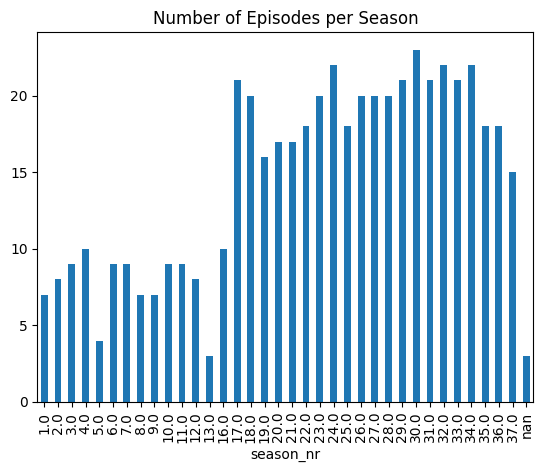

In [8]:
episodes_df['season_nr'].value_counts(dropna=False).sort_index().plot(kind='bar', title='Number of Episodes per Season')

In [11]:
showrunner_cols = [col for col in episodes_df.columns if col.startswith('showrunner_')]
writter_cols = [col for col in episodes_df.columns if col.startswith('written_by_')]

print(episodes_df[showrunner_cols].sum())
print(episodes_df[writter_cols].sum())

showrunner_al_jean            324
showrunner_matt_selman        119
showrunner_mike_scully         34
showrunner_mike_reiss          19
showrunner_bill_oakley         17
showrunner_josh_weinstein      17
showrunner_rob_lazebnik        17
showrunner_brian_kelley        17
showrunner_james_l._brooks     16
showrunner_tim_long            16
showrunner_matt_groening       16
showrunner_sam_simon           16
showrunner_david_mirkin        13
showrunner_michael_price       10
dtype: int64
written_by_joel_h._cohen         35
written_by_jeff_westbrook        29
written_by_john_frink            28
written_by_tim_long              24
written_by_j._stewart_burns      24
written_by_carolyn_omine         22
written_by_michael_price         21
written_by_rob_lazebnik          20
written_by_matt_selman           19
written_by_al_jean               19
written_by_brian_kelley          17
written_by_ian_maxtone-graham    14
written_by_dan_vebber            14
written_by_john_swartzwelder     14
written

## Reviews Database

In [50]:
print(reviews_df.shape)
print(reviews_df['rating'].describe())
reviews_df.head(2)


(66355, 4)
count    66355.000000
mean         3.430050
std          1.271931
min          1.000000
25%          3.000000
50%          4.000000
75%          4.000000
max          5.000000
Name: rating, dtype: float64


,username,episode_name,rating_text,rating
0,Zim999,'Paths of Glory,5/5,5
1,Gatorgod,'Paths of Glory,5/5,5


<Axes: title={'center': 'Distribution of Ratings'}, xlabel='rating'>

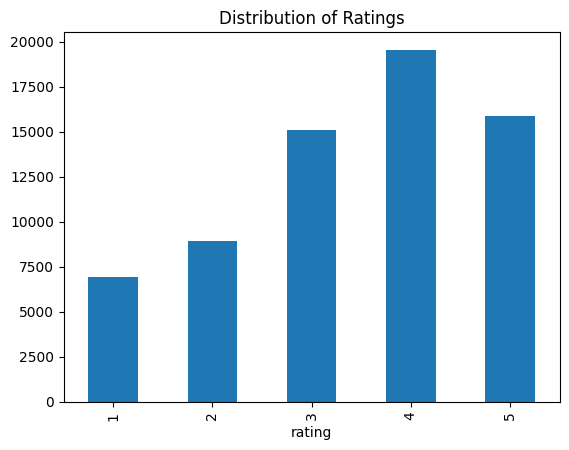

In [ ]:
reviews_df.rating.value_counts(dropna=False).sort_index().plot(kind='bar', title='Distribution of Ratings')
plt.show()


             mean       count
count  511.000000  511.000000
mean     3.291278  129.853229
std      0.713665   80.237857
min      1.571429    8.000000
25%      2.799104   61.000000
50%      3.280255  110.000000
75%      3.766002  183.500000
max      4.865517  396.000000


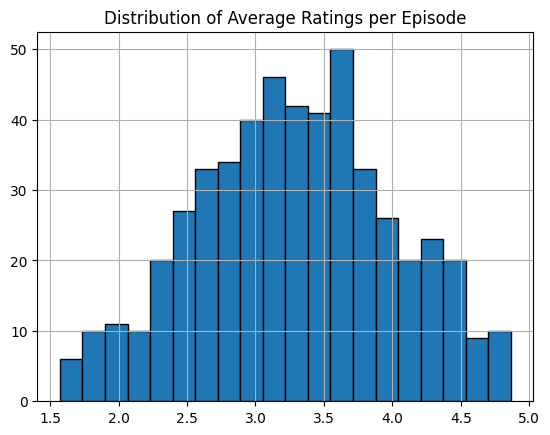

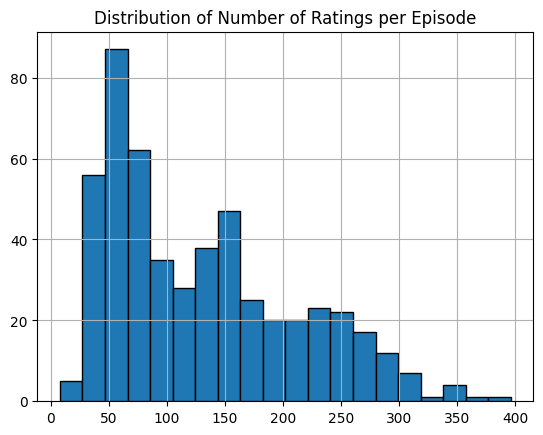

In [51]:
episodes_ratings = (
    reviews_df
    .groupby('episode_name')
    .agg({'rating': ['mean', 'count']})['rating']
    .sort_values('count', ascending=False)
)

print(episodes_ratings.describe())

# Hist AVG Rating
episodes_ratings['mean'].hist(
    bins=20, 
    edgecolor='black'
)
plt.title('Distribution of Average Ratings per Episode')
plt.show()


# Hist Number of Ratings per Episode
episodes_ratings['count'].hist(
    bins=20, 
    edgecolor='black'
)
plt.title('Distribution of Number of Ratings per Episode')
plt.show()

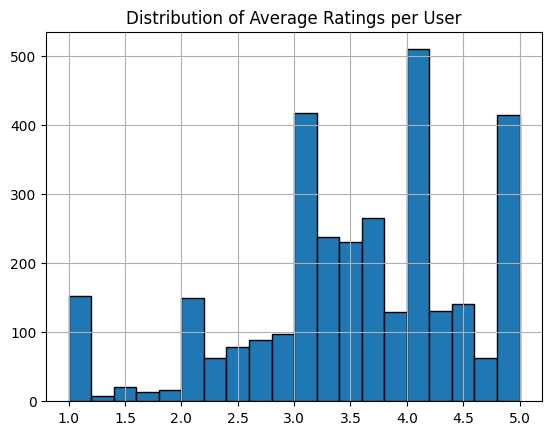

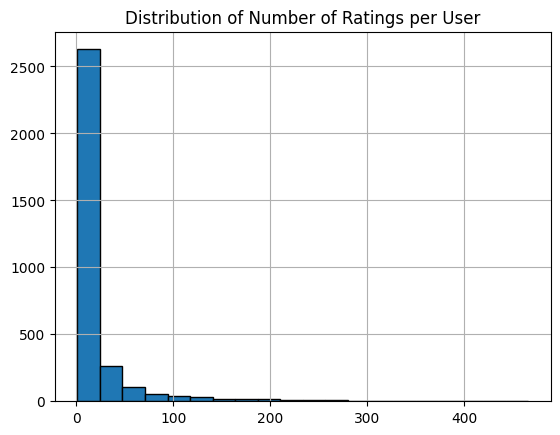

In [47]:
user_ratings = (
    reviews_df
    .groupby('username')
    .agg({'rating': ['mean', 'count']})['rating']
    .sort_values('count', ascending=False)
)

# Hist AVG Rating
user_ratings['mean'].hist(
    bins=20, 
    edgecolor='black'
)
plt.title('Distribution of Average Ratings per User')
plt.show()


# Hist Number of Ratings per Episode
user_ratings['count'].hist(
    bins=20, 
    edgecolor='black'
)
plt.title('Distribution of Number of Ratings per User')
plt.show()

## Ratings x Episode

In [57]:
ratings_episodes = episodes_df.merge(
    reviews_df, 
    how='left', 
    left_on='episode_name', 
    right_on='episode_name'
)

# Check for episodes w/o ratings
ratings_episodes[ratings_episodes['rating'].isna()][['episode_name', 'season_nr']]

,episode_name,season_nr
10061,Burns' Heir,5.0
10062,Bye Bye Nerdie,12.0
14094,E. Pluribus Wiggum,19.0
14095,Faith Off,11.0
21962,Homer the Smithers,7.0
23831,Husbands and Knives,19.0
42329,Secrets of a Successful Marriage,5.0
45565,Summer of 4ft 2,7.0
54903,The Ned-liest Catch,22.0
55340,The PTA Disbands,6.0


### Ratings per Season

In [84]:
ratings_episodes

,episode_name,main_image_url,season_nr,episode_number,original_airdate,written_by,synopsis,show_runners,showrunner_al_jean,showrunner_matt_selman,...,written_by_dan_vebber,written_by_john_swartzwelder,written_by_dan_greaney,written_by_ryan_koh,written_by_bill_odenkirk,written_by_stephanie_gillis,written_by_jon_vitti,username,rating_text,rating
0,'Paths of Glory,https://static.simpsonswiki.com/images/thumb/9...,27.0,['582'],['2015'],['Michael Ferris'],When Lisa sets out to restore the tarnished re...,['Al Jean'],1,0,...,0,0,0,0,0,0,0,Zim999,5/5,5.0
1,'Paths of Glory,https://static.simpsonswiki.com/images/thumb/9...,27.0,['582'],['2015'],['Michael Ferris'],When Lisa sets out to restore the tarnished re...,['Al Jean'],1,0,...,0,0,0,0,0,0,0,Gatorgod,5/5,5.0
2,'Paths of Glory,https://static.simpsonswiki.com/images/thumb/9...,27.0,['582'],['2015'],['Michael Ferris'],When Lisa sets out to restore the tarnished re...,['Al Jean'],1,0,...,0,0,0,0,0,0,0,Bart's treehouse,5/5,5.0
3,'Paths of Glory,https://static.simpsonswiki.com/images/thumb/9...,27.0,['582'],['2015'],['Michael Ferris'],When Lisa sets out to restore the tarnished re...,['Al Jean'],1,0,...,0,0,0,0,0,0,0,JuniorGustabo,5/5,5.0
4,'Paths of Glory,https://static.simpsonswiki.com/images/thumb/9...,27.0,['582'],['2015'],['Michael Ferris'],When Lisa sets out to restore the tarnished re...,['Al Jean'],1,0,...,0,0,0,0,0,0,0,Kaine,5/5,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66361,¡The Fall Guy-Yi-Yi!,https://static.simpsonswiki.com/images/thumb/d...,37.0,['802'],['2025'],['Cesar Mazariegos'],Homer revitalizes Bumblebee Man 's career when...,"['Matt Selman', 'Cesar Mazariegos']",0,1,...,0,0,0,0,0,0,0,Pigeonrat9,3/5,3.0
66362,¡The Fall Guy-Yi-Yi!,https://static.simpsonswiki.com/images/thumb/d...,37.0,['802'],['2025'],['Cesar Mazariegos'],Homer revitalizes Bumblebee Man 's career when...,"['Matt Selman', 'Cesar Mazariegos']",0,1,...,0,0,0,0,0,0,0,funkmasterfuma,3/5,3.0
66363,¡The Fall Guy-Yi-Yi!,https://static.simpsonswiki.com/images/thumb/d...,37.0,['802'],['2025'],['Cesar Mazariegos'],Homer revitalizes Bumblebee Man 's career when...,"['Matt Selman', 'Cesar Mazariegos']",0,1,...,0,0,0,0,0,0,0,JustTakeIt,3/5,3.0
66364,¡The Fall Guy-Yi-Yi!,https://static.simpsonswiki.com/images/thumb/d...,37.0,['802'],['2025'],['Cesar Mazariegos'],Homer revitalizes Bumblebee Man 's career when...,"['Matt Selman', 'Cesar Mazariegos']",0,1,...,0,0,0,0,0,0,0,coramarie,2/5,2.0


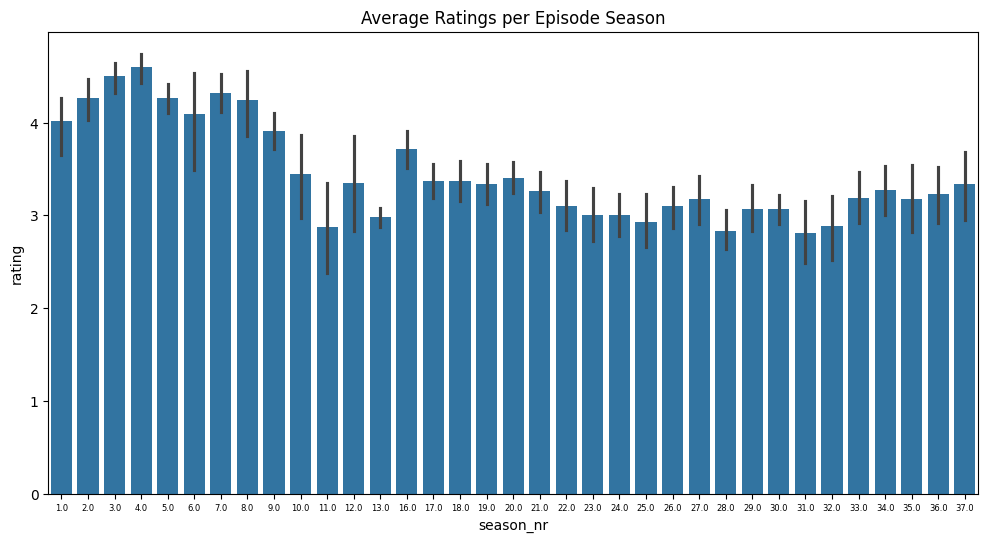

In [87]:
fig, ax = plt.subplots(figsize=(12, 6))

avg_rating_episodes = ratings_episodes.groupby(['episode_name', 'season_nr'])['rating'].mean().reset_index()

sns.barplot(
    data=avg_rating_episodes,
    x='season_nr',
    y='rating',
)
plt.title('Average Ratings per Episode Season')
plt.xticks(fontsize=6)
plt.show()


### Ratings per Writter & Showrunner

In [ ]:
## Writter & Showrunner average ratings
writter_cols = [col for col in episodes_df.columns if col.startswith('written_by_')]
showrunner_cols = [col for col in episodes_df.columns if col.startswith('showrunner_')]

avg_rating_episodes = ratings_episodes.groupby(['episode_name']+writter_cols+showrunner_cols).agg({'rating': 'mean'}).reset_index()

# Create a new DataFrame to store the ratings for each writter and showrunner
wr_sr_ratings = pd.DataFrame()

for col in writter_cols + showrunner_cols:
    wr_sr_ratings[col] = np.where(avg_rating_episodes[col] == 1, avg_rating_episodes['rating'], np.nan)


In [ ]:
# Writters
wr_sr_ratings[writter_cols].agg(['mean', 'count']).T.sort_values('count', ascending=False).head(10)

,mean,count
written_by_joel_h._cohen,3.040857,35.0
written_by_jeff_westbrook,2.941493,28.0
written_by_john_frink,3.077031,27.0
written_by_tim_long,2.963177,24.0
written_by_j._stewart_burns,3.029893,23.0
written_by_carolyn_omine,3.407760,22.0
written_by_michael_price,2.999526,20.0
written_by_rob_lazebnik,2.990108,20.0
written_by_al_jean,3.345896,19.0
written_by_matt_selman,3.513739,18.0


In [ ]:
# Showrunners
wr_sr_ratings[showrunner_cols].agg(['mean', 'count']).T.sort_values('count', ascending=False).head(10)

,mean,count
showrunner_al_jean,3.107314,321.0
showrunner_matt_selman,3.483072,118.0
showrunner_mike_scully,3.290811,32.0
showrunner_mike_reiss,4.545531,19.0
showrunner_brian_kelley,3.614447,17.0
showrunner_rob_lazebnik,3.209837,17.0
showrunner_matt_groening,4.166317,16.0
showrunner_sam_simon,4.166317,16.0
showrunner_james_l._brooks,4.166317,16.0
showrunner_tim_long,3.189319,16.0
